<a href="https://colab.research.google.com/github/nngiabao/AIDevFundamental/blob/main/FreshRottenFruit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#link: https://www.kaggle.com/datasets/abdulrafeyyashir/fresh-vs-rotten-fruit-images

In [ ]:
from google.colab import files
files.upload()

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets download -d abdulrafeyyashir/fresh-vs-rotten-fruit-images

Dataset URL: https://www.kaggle.com/datasets/abdulrafeyyashir/fresh-vs-rotten-fruit-images
License(s): apache-2.0
  0% 0.00/38.5M [00:00<?, ?B/s]
100% 38.5M/38.5M [00:00<00:00, 758MB/s]


In [5]:
#unzip file
!unzip fresh-vs-rotten-fruit-images.zip -d fruit_images


Archive:  fresh-vs-rotten-fruit-images.zip
  inflating: fruit_images/Fruit Freshness Dataset/Fruit Freshness Dataset/Apple/Fresh/apple_fresh_001.jpg (1).jpg  
  inflating: fruit_images/Fruit Freshness Dataset/Fruit Freshness Dataset/Apple/Fresh/apple_fresh_001.jpg (1).png  
  inflating: fruit_images/Fruit Freshness Dataset/Fruit Freshness Dataset/Apple/Fresh/apple_fresh_001.jpg (1).webp  
  inflating: fruit_images/Fruit Freshness Dataset/Fruit Freshness Dataset/Apple/Fresh/apple_fresh_001.jpg (100).jpg  
  inflating: fruit_images/Fruit Freshness Dataset/Fruit Freshness Dataset/Apple/Fresh/apple_fresh_001.jpg (101).jpg  
  inflating: fruit_images/Fruit Freshness Dataset/Fruit Freshness Dataset/Apple/Fresh/apple_fresh_001.jpg (102).jpg  
  inflating: fruit_images/Fruit Freshness Dataset/Fruit Freshness Dataset/Apple/Fresh/apple_fresh_001.jpg (103).jpg  
  inflating: fruit_images/Fruit Freshness Dataset/Fruit Freshness Dataset/Apple/Fresh/apple_fresh_001.jpg (104).jpg  
  inflating: fruit

In [6]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

In [7]:
path = '/content/fruit_images/Fruit Freshness Dataset/Fruit Freshness Dataset'
os.listdir(path)

['Apple', 'Banana', 'Strawberry']

In [8]:
strawberry_path = os.path.join(path, 'Strawberry')
apple_path = os.path.join(path, 'Apple')
banana_path = os.path.join(path, 'Banana')

print(f"Strawberry directory: {strawberry_path}")
print(f"Apple directory: {apple_path}")
print(f"Banana directory: {banana_path}")

Strawberry directory: /content/fruit_images/Fruit Freshness Dataset/Fruit Freshness Dataset/Strawberry
Apple directory: /content/fruit_images/Fruit Freshness Dataset/Fruit Freshness Dataset/Apple
Banana directory: /content/fruit_images/Fruit Freshness Dataset/Fruit Freshness Dataset/Banana


In [9]:
#labels
labels = []
images = []

fruit_types = os.listdir(path)

for fruit_type in fruit_types:
    fruit_dir = os.path.join(path, fruit_type)

    if os.path.isdir(fruit_dir):
      freshness_types = os.listdir(fruit_dir)

      for freshness_type in freshness_types:
          freshness_dir = os.path.join(fruit_dir, freshness_type)

          if os.path.isdir(freshness_dir):
             for image_filename in os.listdir(freshness_dir):
                 if image_filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                    image_path = os.path.join(freshness_dir, image_filename)
                    images.append(image_path)
                    labels.append(freshness_type)

print(f"Collected {len(images)} images and {len(labels)} labels.")

Collected 529 images and 529 labels.


In [10]:
df = pd.DataFrame({'image_path': images, 'label': labels})
df.head()

,image_path,label
0,/content/fruit_images/Fruit Freshness Dataset/...,Rotten
1,/content/fruit_images/Fruit Freshness Dataset/...,Rotten
2,/content/fruit_images/Fruit Freshness Dataset/...,Rotten
3,/content/fruit_images/Fruit Freshness Dataset/...,Rotten
4,/content/fruit_images/Fruit Freshness Dataset/...,Rotten


Text(0.5, 0, 'Label')

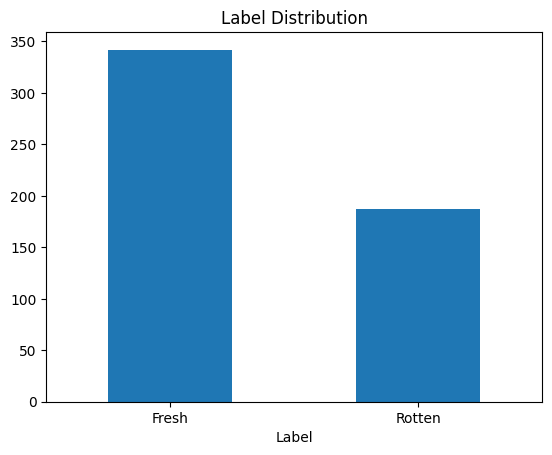

In [11]:
df['label'].value_counts(ascending=False).plot(kind='bar', title='Label Distribution')
plt.xticks(rotation=0)
plt.xlabel('Label')

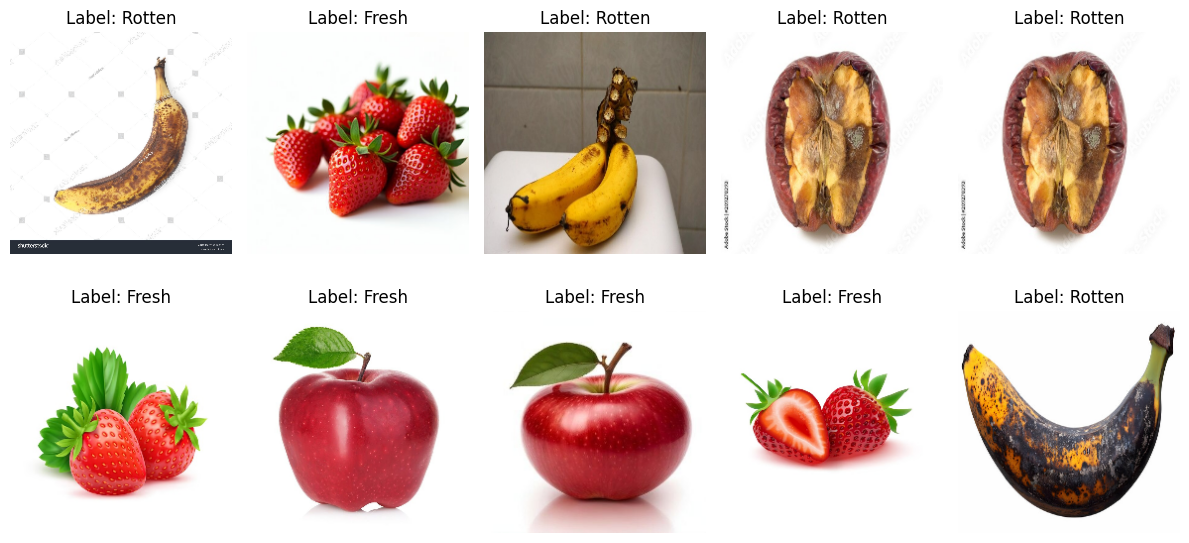

In [12]:
import cv2
labels = df['label'].unique()

plt.figure(figsize=(12, 6))

for i in range(10):
  random_index = random.randint(0, len(df) - 1)
  image_path = df.iloc[random_index]['image_path']
  label = df.iloc[random_index]['label']

  img = plt.imread(image_path).copy()
  resized_img = cv2.resize(img, (224, 224))
  plt.subplot(2, 5, i+1)
  plt.imshow(resized_img)
  plt.title(f"Label: {label}")
  plt.axis('off')

plt.tight_layout()
plt.show()

In [13]:
#preparing
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df['image_path'], df['label'], test_size=0.2, random_state=42)

train_df = pd.DataFrame({'image_path': X_train, 'label': y_train})
test_df = pd.DataFrame({'image_path': X_test, 'label': y_test})

In [14]:
train_df.head()

,image_path,label
137,/content/fruit_images/Fruit Freshness Dataset/...,Fresh
525,/content/fruit_images/Fruit Freshness Dataset/...,Fresh
416,/content/fruit_images/Fruit Freshness Dataset/...,Fresh
371,/content/fruit_images/Fruit Freshness Dataset/...,Fresh
69,/content/fruit_images/Fruit Freshness Dataset/...,Fresh


In [15]:
train_df.shape

(423, 2)

# Data processing

In [17]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf
from sklearn.model_selection import train_test_split

train_augmentaion = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_gen = ImageDataGenerator(rescale=1./255)

In [18]:
#
train_dataset = train_augmentaion.flow_from_dataframe(
    dataframe=train_df,
    x_col='image_path',
    y_col='label',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=True
)

test_dataset = test_gen.flow_from_dataframe(
    dataframe=test_df,
    x_col='image_path',
    y_col='label',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 423 validated image filenames belonging to 2 classes.
Found 106 validated image filenames belonging to 2 classes.


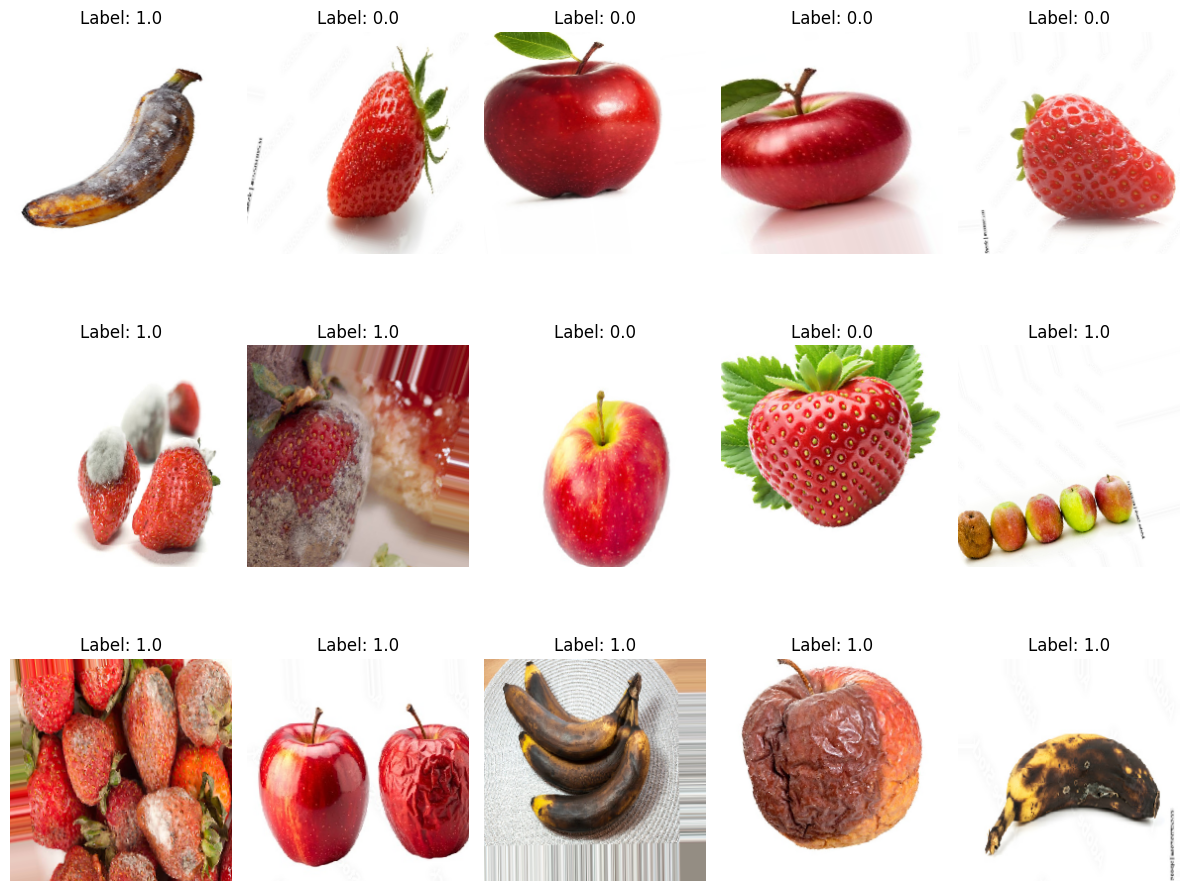

In [19]:
#Visualizing some train data agumented
iamges, labels = next(train_dataset)

plt.figure(figsize=(12, 10))
for i in range(15):
  plt.subplot(3, 5, i+1)
  plt.imshow(iamges[i])
  plt.title(f"Label: {labels[i]}")
  plt.axis('off')

plt.tight_layout()
plt.show()

# Creating the model

In [21]:
#Setting up callbacks
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

early_stopping = EarlyStopping(monitor='val_loss', patience=5, verbose=1, restore_best_weights=True)

model_checkpoint = ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True, verbose=1)

lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, verbose=1, min_lr=1e-6)



In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D, Input

model = Sequential([
    Input(shape=(224, 224, 3)),
    # First layer
    Conv2D(32, kernel_size=3, activation='relu'),
    MaxPooling2D(),

    # Second layer
    Conv2D(64, kernel_size=3, activation='relu'),
    MaxPooling2D(),

    # Third layer
    Conv2D(128, kernel_size=3, activation='relu'),
    MaxPooling2D(),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
], name='model')

model.compile(
    loss='binary_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=['accuracy']
)

model.summary()

Model: "model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
model_history = model.fit(
    train_dataset,
    steps_per_epoch=len(train_dataset),
    validation_data=test_dataset,
    validation_steps=len(test_dataset),
    epochs=10,
    callbacks=[early_stopping, model_checkpoint, lr_scheduler]
)

Epoch 1/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8595 - loss: 0.3385
Epoch 1: val_loss did not improve from 0.28557
14/14 ━━━━━━━━━━━━━━━━━━━━ 51s 4s/step - accuracy: 0.8612 - loss: 0.3359 - val_accuracy: 0.7925 - val_loss: 0.4645 - learning_rate: 0.0010
Epoch 2/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8533 - loss: 0.3275
Epoch 2: val_loss improved from 0.28557 to 0.20347, saving model to best_model.h5


14/14 ━━━━━━━━━━━━━━━━━━━━ 81s 4s/step - accuracy: 0.8543 - loss: 0.3266 - val_accuracy: 0.9340 - val_loss: 0.2035 - learning_rate: 0.0010
Epoch 3/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8940 - loss: 0.2540
Epoch 3: val_loss did not improve from 0.20347
14/14 ━━━━━━━━━━━━━━━━━━━━ 51s 4s/step - accuracy: 0.8933 - loss: 0.2561 - val_accuracy: 0.8585 - val_loss: 0.2903 - learning_rate: 0.0010
Epoch 4/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8888 - loss: 0.2847
Epoch 4: val_loss improved from 0.20347 to 0.14875, saving model to best_model.h5


14/14 ━━━━━━━━━━━━━━━━━━━━ 82s 4s/step - accuracy: 0.8902 - loss: 0.2833 - val_accuracy: 0.9528 - val_loss: 0.1488 - learning_rate: 0.0010
Epoch 5/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8993 - loss: 0.2654
Epoch 5: val_loss improved from 0.14875 to 0.12739, saving model to best_model.h5


14/14 ━━━━━━━━━━━━━━━━━━━━ 88s 4s/step - accuracy: 0.8987 - loss: 0.2658 - val_accuracy: 0.9528 - val_loss: 0.1274 - learning_rate: 0.0010
Epoch 6/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9202 - loss: 0.2019
Epoch 6: val_loss did not improve from 0.12739
14/14 ━━━━━━━━━━━━━━━━━━━━ 79s 4s/step - accuracy: 0.9191 - loss: 0.2052 - val_accuracy: 0.9151 - val_loss: 0.2167 - learning_rate: 0.0010
Epoch 7/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9236 - loss: 0.2302
Epoch 7: val_loss did not improve from 0.12739
14/14 ━━━━━━━━━━━━━━━━━━━━ 79s 4s/step - accuracy: 0.9226 - loss: 0.2305 - val_accuracy: 0.8774 - val_loss: 0.2709 - learning_rate: 0.0010
Epoch 8/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9123 - loss: 0.2058
Epoch 8: val_loss did not improve from 0.12739

Epoch 8: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
14/14 ━━━━━━━━━━━━━━━━━━━━ 81s 4s/step - accuracy: 0.9122 - loss: 0.2067 - val_accuracy: 0.8962 - val_loss: 0.2620 

# Evaluating and testing the results

In [24]:
model.evaluate(test_dataset)

4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 741ms/step - accuracy: 0.9582 - loss: 0.1263


[0.12738651037216187, 0.9528301954269409]

In [26]:
from tensorflow.keras.models import load_model

model = load_model('best_model.h5')

preds = model.predict(test_dataset)

4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 691ms/step


In [27]:
import numpy as np

class_indices = train_dataset.class_indices

idx_to_class = {v: k for k, v in class_indices.items()}

# Corrected prediction for binary classification
predicted_class_indices = (preds > 0.5).astype(int).flatten() # Threshold at 0.5 and flatten

predicted_classes = [idx_to_class[idx] for idx in predicted_class_indices]

print("First 10 predicted class labels")
for i, label in enumerate(predicted_classes[:10]):
  print(f"Image {i+1}: {label}")

test_df['predicted_label'] = predicted_classes

display(test_df.head(10))

First 10 predicted class labels
Image 1: Fresh
Image 2: Fresh
Image 3: Rotten
Image 4: Fresh
Image 5: Fresh
Image 6: Fresh
Image 7: Rotten
Image 8: Fresh
Image 9: Fresh
Image 10: Fresh


,image_path,label,predicted_label
140,/content/fruit_images/Fruit Freshness Dataset/...,Fresh,Fresh
397,/content/fruit_images/Fruit Freshness Dataset/...,Fresh,Fresh
6,/content/fruit_images/Fruit Freshness Dataset/...,Rotten,Rotten
334,/content/fruit_images/Fruit Freshness Dataset/...,Fresh,Fresh
322,/content/fruit_images/Fruit Freshness Dataset/...,Fresh,Fresh
82,/content/fruit_images/Fruit Freshness Dataset/...,Fresh,Fresh
225,/content/fruit_images/Fruit Freshness Dataset/...,Rotten,Rotten
495,/content/fruit_images/Fruit Freshness Dataset/...,Fresh,Fresh
522,/content/fruit_images/Fruit Freshness Dataset/...,Fresh,Fresh
101,/content/fruit_images/Fruit Freshness Dataset/...,Fresh,Fresh


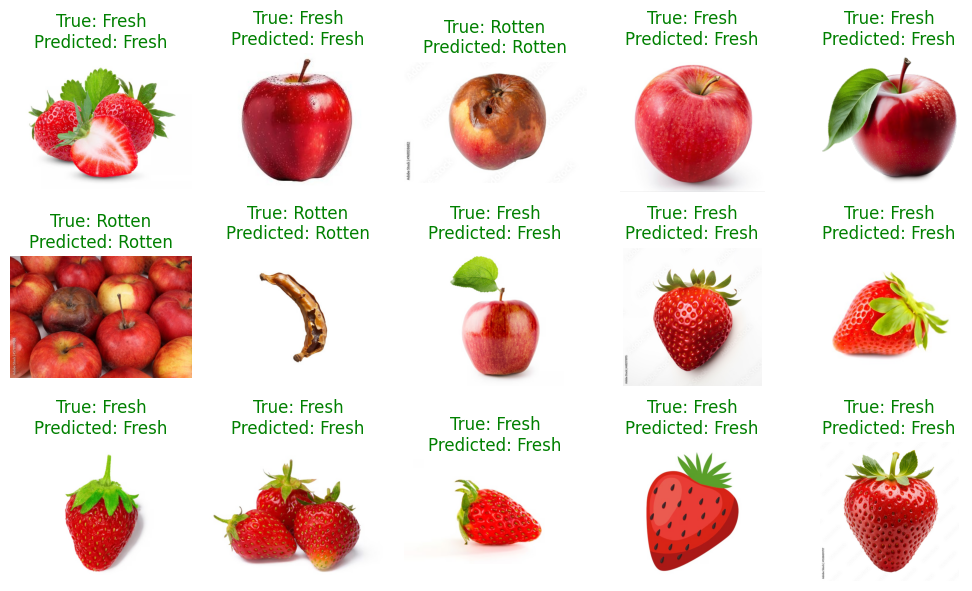

In [28]:
# Visualizing predictions

fig, ax = plt.subplots(3, 5, figsize=(10, 6))
ax = ax.ravel()

for i in range(15):
  idx = random.randint(0, len(test_df) - 1)
  image_path = test_df.iloc[idx]['image_path']
  true_label = test_df.iloc[idx]['label']
  predicted_label = test_df.iloc[idx]['predicted_label']

  if true_label == predicted_label:
    color = 'green'
  else:
    color = 'red'

  img = plt.imread(image_path)
  ax[i].imshow(img)
  ax[i].set_title(f"True: {true_label}\nPredicted: {predicted_label}", color=color)
  ax[i].axis('off')

plt.tight_layout()
plt.show()